# July 1 Triggered-Dip Systematics

This notebook tests whether MALCA's **individual detector-kept dip runs** cluster in observing night, physical distance, sky position, ASAS-SN field, or camera. It follows Tzanidakis et al. (2025 draft), §3.4 and Figure 3, while keeping angular separation and run-interval separation explicit instead of combining them through the paper's constructed `r = c × t_dip` distance.

The review database stores run counts but not individual run epochs. The first analysis cell therefore replays the exact historical detector source snapshot recorded by the July 1 run and caches one row per recovered run. Counts are reconciled against `dip_run_count`; any small numerical replay mismatch is retained as an explicit QC warning rather than substituted with a best-dip point. The database and bundled light curves remain read-only.


## Parameters and imports

The first code cell is tagged `parameters`. Run replay is resumable and normally reads the completed cache. Source-block permutations preserve every source's recurring run schedule.


In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from functools import lru_cache
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/malca-mplconfig")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
from IPython.display import Markdown, display

from malca.io.lightcurve_io import load_lightcurve_df
from malca.io.notebook_paths import find_repo_root, resolve_local_lightcurve_path, resolve_repo_path
from malca.meta_analysis.triggered_dip_systematics import (
    build_nearby_run_pairs,
    distance_time_source_block_permutation_test,
    load_review_candidates,
    prepare_triggered_dip_runs,
    summarize_nights,
    summarize_run_pair_excess,
    triggered_run_group_rates,
)

REPO_ROOT = find_repo_root()
RUN_ROOT = REPO_ROOT / "output" / "runs" / "dat3-full-extended_2026-07-01-v4"
REVIEW_DB = RUN_ROOT / "review" / "review.db"
OUTPUT_DIR = REPO_ROOT / "output" / "notebooks" / "july1_triggered_dip_systematics"

WRITE_OUTPUTS = os.environ.get("MALCA_SYSTEMATICS_WRITE_OUTPUTS", "1").strip().lower() not in {"0", "false", "no", "off"}
RUN_TABLE = OUTPUT_DIR / "triggered_dip_runs.parquet"
RUN_EXPOSURES = OUTPUT_DIR / "triggered_dip_runs_exposures.parquet"
RUN_STATUS = OUTPUT_DIR / "triggered_dip_runs_replay_status.parquet"
AUTO_BUILD_RUN_TABLE = os.environ.get("MALCA_SYSTEMATICS_BUILD_RUN_TABLE", "1").strip().lower() not in {"0", "false", "no", "off"}
RUN_REPLAY_WORKERS = int(os.environ.get("MALCA_SYSTEMATICS_RUN_WORKERS", "12"))
N_PERMUTATIONS = int(os.environ.get("MALCA_SYSTEMATICS_N_PERM", "200"))
RANDOM_STATE = 20260721
PAIR_MAX_SEP_DEG = float(os.environ.get("MALCA_SYSTEMATICS_PAIR_MAX_SEP_DEG", "2.0"))
PAIR_ANGULAR_BINS_DEG = tuple(sorted({value for value in (0.1, 0.25, 0.5, 1.0, 2.0, 5.0, PAIR_MAX_SEP_DEG) if value <= PAIR_MAX_SEP_DEG}))
PAIR_LAG_THRESHOLDS_DAYS = (0.5, 1.0, 7.0)
FLAG_ANGULAR_DEG = 0.5
FLAG_LAG_DAYS = 1.0
WRITE_FULL_PAIR_TABLE = True
PLOT_TOP_PAIR_LIGHTCURVES = os.environ.get("MALCA_SYSTEMATICS_PLOT_TOP_PAIRS", "1").strip().lower() not in {"0", "false", "no", "off"}
TOP_PAIR_PANELS = 4
PLOT_ALL_FLAGGED_PAIR_LIGHTCURVES = os.environ.get("MALCA_SYSTEMATICS_PLOT_ALL_FLAGGED_PAIRS", "1").strip().lower() not in {"0", "false", "no", "off"}
ALL_FLAGGED_PAIRS_PER_PAGE = int(os.environ.get("MALCA_SYSTEMATICS_FLAGGED_PAIRS_PER_PAGE", "6"))
MAX_FLAGGED_PAIR_PLOTS = int(os.environ.get("MALCA_SYSTEMATICS_MAX_FLAGGED_PAIR_PLOTS", "500"))
PANEL_HALF_WINDOW_DAYS = 40.0

RUN_ROOT = resolve_repo_path(RUN_ROOT, repo_root=REPO_ROOT)
REVIEW_DB = resolve_repo_path(REVIEW_DB, repo_root=REPO_ROOT)
OUTPUT_DIR = resolve_repo_path(OUTPUT_DIR, repo_root=REPO_ROOT)
assert RUN_ROOT is not None and RUN_ROOT.is_dir(), RUN_ROOT
assert REVIEW_DB is not None and REVIEW_DB.is_file(), REVIEW_DB
assert OUTPUT_DIR is not None
assert RUN_REPLAY_WORKERS >= 1, RUN_REPLAY_WORKERS
assert ALL_FLAGGED_PAIRS_PER_PAGE >= 1, ALL_FLAGGED_PAIRS_PER_PAGE
if WRITE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    legacy_best_point_artifacts = (
        "event_qc.parquet", "event_table.parquet", "field_camera_rates.csv",
        "candidate_field_camera_trigger_rates.png", "candidate_field_camera_trigger_rates.pdf",
        "night_camera_field_rates.csv", "cache/event_attribution.parquet",
        "cache/night_camera_field_exposures.parquet", "cache/scan_metadata.json",
        "cache/scan_selection.parquet",
    )
    for relative_path in legacy_best_point_artifacts:
        (OUTPUT_DIR / relative_path).unlink(missing_ok=True)

print(f"repo root : {REPO_ROOT}")
print(f"run root  : {RUN_ROOT}")
print(f"review DB : {REVIEW_DB}")
print(f"output dir: {OUTPUT_DIR} (writes={WRITE_OUTPUTS})")
print(f"run table : {RUN_TABLE}")


repo root : /Users/calder/code/malca
run root  : /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4
review DB : /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/review/review.db
output dir: /Users/calder/code/malca/output/notebooks/july1_triggered_dip_systematics (writes=True)
run table : /Users/calder/code/malca/output/notebooks/july1_triggered_dip_systematics/triggered_dip_runs.parquet


## Small notebook helpers


In [2]:
def first_column(frame: pd.DataFrame, names: tuple[str, ...] | list[str]) -> str | None:
    return next((name for name in names if name in frame.columns), None)


def finite_numeric(values: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(values, errors="coerce")
    return numeric.where(np.isfinite(numeric))


def write_frame(frame: pd.DataFrame, filename: str) -> Path | None:
    if not WRITE_OUTPUTS:
        return None
    path = OUTPUT_DIR / filename
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.suffix == ".parquet":
        frame.to_parquet(path, index=False)
    elif path.suffix == ".csv":
        frame.to_csv(path, index=False)
    else:
        raise ValueError(f"Unsupported table suffix: {path.suffix}")
    return path


def finish_figure(fig: plt.Figure, stem: str) -> None:
    fig.tight_layout()
    if WRITE_OUTPUTS:
        fig.savefig(OUTPUT_DIR / f"{stem}.png", dpi=220, bbox_inches="tight")
        fig.savefig(OUTPUT_DIR / f"{stem}.pdf", bbox_inches="tight")
    plt.show()


def scalar_from_table(frame: pd.DataFrame, names: tuple[str, ...], default=np.nan):
    column = first_column(frame, list(names))
    if column is None or frame.empty:
        return default
    return frame.iloc[0][column]


def safe_min(frame: pd.DataFrame, names: tuple[str, ...]) -> float:
    column = first_column(frame, list(names))
    if column is None or frame.empty:
        return np.nan
    values = finite_numeric(frame[column])
    return float(values.min()) if values.notna().any() else np.nan


## Recover and validate every triggered dip run

The replay script runs the detector source snapshot whose SHA-256 is recorded by the July 1 run. It checkpoints in batches and reconciles every source against stored `dip_run_count`. Exact matches and any explicitly flagged numerical replay mismatches both remain run-level records; `events` is never replaced by one best point per source.


In [3]:
if not RUN_TABLE.is_file() or not RUN_EXPOSURES.is_file() or not RUN_STATUS.is_file():
    if not AUTO_BUILD_RUN_TABLE:
        raise FileNotFoundError(f"Run table is missing and automatic replay is disabled: {RUN_TABLE}")
    replay_command = [
        sys.executable, str(REPO_ROOT / "scripts" / "extract_triggered_dip_runs.py"),
        "--run-root", str(RUN_ROOT), "--output", str(RUN_TABLE),
        "--workers", str(RUN_REPLAY_WORKERS),
    ]
    print("Building the resumable triggered-run table...")
    subprocess.run(replay_command, cwd=REPO_ROOT, check=True)

candidates = load_review_candidates(REVIEW_DB, include_reviews=True)
run_table = pd.read_parquet(RUN_TABLE)
run_exposures = pd.read_parquet(RUN_EXPOSURES)
replay_status = pd.read_parquet(RUN_STATUS)
assert replay_status["status"].isin({"ok", "count_mismatch"}).all()
assert len(run_table) == int(pd.to_numeric(replay_status["replayed_run_count"], errors="coerce").sum())
events, event_qc = prepare_triggered_dip_runs(run_table, candidates)
valid_qc = event_qc["qc_valid"].fillna(False).astype(bool)
assert valid_qc.all(), event_qc.loc[~valid_qc, ["event_id", "qc_reasons"]].head()
assert events["event_id"].is_unique
significant_source_mask = pd.to_numeric(candidates["dip_significant"], errors="coerce").eq(1)
assert len(replay_status) == int(significant_source_mask.sum())
stored_run_total = int(pd.to_numeric(candidates.loc[significant_source_mask, "dip_run_count"], errors="coerce").fillna(0).sum())
assert int(pd.to_numeric(replay_status["expected_run_count"], errors="coerce").sum()) == stored_run_total
assert run_exposures["source_key"].nunique() == len(candidates)
replay_run_delta = len(events) - stored_run_total

trigger_values = pd.to_numeric(candidates["dip_significant"], errors="coerce")
cohort_table = pd.DataFrame(
    [
        ("review DB candidates", len(candidates)),
        ("sources with significant dip runs", int(trigger_values.eq(1).sum())),
        ("stored triggered dip runs", stored_run_total),
        ("structurally valid replayed dip runs", len(events)),
        ("replay minus stored run total", replay_run_delta),
        ("sources represented in run table", events["source_key"].nunique()),
        ("sources represented in exposure table", run_exposures["source_key"].nunique()),
        ("run-count reconciliation warnings", int(replay_status["status"].eq("count_mismatch").sum())),
    ],
    columns=["cohort", "count"],
)
display(cohort_table)
display(events.groupby("source_key").size().describe().rename("runs_per_source"))


,cohort,count
0,review DB candidates,22942
1,sources with significant dip runs,19867
2,stored triggered dip runs,335362
3,structurally valid replayed dip runs,335360
4,replay minus stored run total,-2
5,sources represented in run table,19866
6,sources represented in exposure table,22942
7,run-count reconciliation warnings,31


count    19866.000000
mean        16.881103
std         14.937755
min          1.000000
25%          6.000000
50%         13.000000
75%         23.000000
max        149.000000
Name: runs_per_source, dtype: float64

In [4]:
event_preview_columns = [
    column
    for column in (
        "event_id", "source_key", "run_number", "ra", "dec", "distance_pc",
        "run_start_jd", "run_end_jd", "dip_jd", "dip_mjd", "dip_night_mjd",
        "run_duration_days", "n_trigger_points", "run_peak_time_source", "run_fit_amp", "run_fit_width_param",
        "run_peak_event_probability", "run_peak_log_bf_local",
        "asassn_field_key", "camera_name_key", "lc_path",
    )
    if column in events.columns
]
display(events[event_preview_columns].head(20))
display(events[event_preview_columns].describe(include="all").T)

write_frame(cohort_table, "cohort_integrity.csv")
write_frame(event_qc, "triggered_dip_run_qc.parquet")
write_frame(events, "triggered_dip_run_events.parquet")


,event_id,source_key,run_number,ra,dec,distance_pc,run_start_jd,run_end_jd,dip_jd,dip_mjd,...,run_duration_days,n_trigger_points,run_peak_time_source,run_fit_amp,run_fit_width_param,run_peak_event_probability,run_peak_log_bf_local,asassn_field_key,camera_name_key,lc_path
0,stv_377957474869:dip_run_0001,stv_377957474869,1,116.256869,-7.787565,2025.634033,2.456659e+06,2.456759e+06,2.456659e+06,56658.363197,...,99.89612,2,morphology_fit_t0,2.523005e-01,46.944568,1.0,162.351569,F0751-06_1472,bb,/Users/calder/code/malca/output/runs/dat3-full...
1,stv_249108300210:dip_run_0001,stv_249108300210,1,145.735409,20.048400,836.785400,2.456659e+06,2.456659e+06,2.456659e+06,56658.379790,...,0.02139,2,max_trigger_sample,3.146315e-01,0.542591,1.0,28.162478,F0943+22_0435,bc,/Users/calder/code/malca/output/runs/dat3-full...
2,stv_292057924584:dip_run_0001,stv_292057924584,1,135.699525,-4.556647,454.813995,2.456659e+06,2.456742e+06,2.456659e+06,56658.385030,...,82.95403,2,max_trigger_sample,1.291152e-01,146.869346,1.0,106.288923,F0910-06_1481,ba,/Users/calder/code/malca/output/runs/dat3-full...
3,stv_197569314737:dip_run_0001,stv_197569314737,1,84.776832,8.046214,1166.182495,2.456659e+06,2.456731e+06,2.456659e+06,56658.391970,...,71.87917,3,morphology_fit_t0,2.985026e-01,9.255355,1.0,385.763537,F0538+06_0043,bc,/Users/calder/code/malca/output/runs/dat3-full...
4,stv_197569349203:dip_run_0001,stv_197569349203,1,85.939978,8.149236,1831.539062,2.456659e+06,2.456679e+06,2.456659e+06,56658.424358,...,19.98122,2,morphology_fit_t0,1.432347e-01,895.571854,1.0,32.276500,F0538+06_0043,bc,/Users/calder/code/malca/output/runs/dat3-full...
5,stv_25769963836:dip_run_0001,stv_25769963836,1,108.477994,56.295826,1523.352051,2.456659e+06,2.456737e+06,2.456659e+06,56658.428390,...,77.82071,2,max_trigger_sample,2.559487e+00,5.485965,1.0,294.944953,F0725+58_1160,bb,/Users/calder/code/malca/output/runs/dat3-full...
6,stv_309238014314:dip_run_0001,stv_309238014314,1,184.540005,-5.903283,1046.624512,2.456659e+06,2.456753e+06,2.456659e+06,56658.551490,...,93.81985,2,morphology_fit_t0,5.004989e-01,452.953211,1.0,48.406213,F1218-06_1505,ba,/Users/calder/code/malca/output/runs/dat3-full...
7,stv_128850416761:dip_run_0001,stv_128850416761,1,237.237948,58.889925,841.195129,2.456659e+06,2.456772e+06,2.456659e+06,56658.623190,...,112.97467,3,max_trigger_sample,1.138214e+00,9.942565,1.0,142.233820,F1545+58_1196,bb,/Users/calder/code/malca/output/runs/dat3-full...
8,stv_498216929369:dip_run_0001,stv_498216929369,1,217.086119,-31.762743,6905.209961,2.456659e+06,2.456659e+06,2.456659e+06,56658.641630,...,0.00026,2,max_trigger_sample,NaN,NaN,1.0,43.303002,F1419-30_2052,bb,/Users/calder/code/malca/output/runs/dat3-full...
9,stv_566936811481:dip_run_0001,stv_566936811481,1,159.765066,-31.978151,2872.156494,2.456659e+06,2.456683e+06,2.456673e+06,56672.105507,...,23.92588,2,morphology_fit_t0,2.965778e-01,10.894566,1.0,114.601581,F1037-30_2025,ba,/Users/calder/code/malca/output/runs/dat3-full...


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
event_id,335360,335360,stv_377957474869:dip_run_0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_key,335360,19866,stv_515396161371,149,NaN,NaN,NaN,NaN,NaN,NaN,NaN
run_number,335360.0,NaN,NaN,NaN,15.549281,14.751526,1.0,5.0,11.0,21.0,149.0
ra,335360.0,NaN,NaN,NaN,188.003192,92.461668,0.02284,110.535191,176.273969,275.226714,359.966614
dec,335360.0,NaN,NaN,NaN,-12.883264,40.407659,-89.064059,-48.581037,-18.092752,19.821905,88.051127
distance_pc,253763.0,NaN,NaN,NaN,1498.298094,1341.307973,9.9074,808.793884,1166.493042,1756.78479,29166.59375
run_start_jd,335360.0,NaN,NaN,NaN,2459404.702252,1094.242078,2456658.76014,2458575.65413,2459486.78784,2460351.561085,2461216.49214
run_end_jd,335360.0,NaN,NaN,NaN,2459417.073456,1092.330969,2456658.90118,2458582.525775,2459497.534245,2460357.846753,2461217.86283
dip_jd,335360.0,NaN,NaN,NaN,2459409.06497,1093.635854,2456658.863197,2458578.024795,2459490.78764,2460353.527197,2461216.51418
dip_mjd,335360.0,NaN,NaN,NaN,59408.56497,1093.635854,56658.363197,58577.524795,59490.28764,60353.027197,61216.01418


PosixPath('/Users/calder/code/malca/output/notebooks/july1_triggered_dip_systematics/triggered_dip_run_events.parquet')

## Paper-style one-day dip-night distribution

The upper panel bins the fitted center of every detector-kept dip run into one-day MJD bins (falling back to its strongest trigger sample when a run has no valid fit). A source with recurring dips contributes multiple runs. The lower panel uses the number of candidates whose stored observing spans cover that night as an approximate availability denominator. Poisson-tail and BH-adjusted values are descriptive screens, not automatic rejection rules.


,night_mjd,n_events,n_exposed_sources,exposure_source,event_rate,expected_events,pvalue,qvalue,night
1919,58577,243,22939,candidate_baseline_approximation,0.010593,82.055780,8.108195e-47,1.848263e-43,2019-04-04
1922,58580,240,22939,candidate_baseline_approximation,0.010463,82.055780,2.092958e-45,3.180598e-42,2019-04-07
4431,61089,239,21059,candidate_baseline_approximation,0.011349,75.330776,6.527405e-51,2.975844e-47,2026-02-18
2068,58726,232,22940,candidate_baseline_approximation,0.010113,82.059357,1.020753e-41,9.307221e-39,2019-08-31
1946,58604,231,22939,candidate_baseline_approximation,0.010070,82.055780,2.873820e-41,2.183624e-38,2019-05-01
3390,60048,228,22930,candidate_baseline_approximation,0.009943,82.023585,6.017723e-40,3.919257e-37,2023-04-14
4434,61092,225,20996,candidate_baseline_approximation,0.010716,75.105416,3.040753e-44,3.465698e-41,2026-02-21
3014,59672,225,22938,candidate_baseline_approximation,0.009809,82.052202,1.350908e-38,6.886046e-36,2022-04-03
1912,58570,225,22939,candidate_baseline_approximation,0.009809,82.055780,1.359386e-38,6.886046e-36,2019-03-28
1921,58579,224,22939,candidate_baseline_approximation,0.009765,82.055780,3.736858e-38,1.703634e-35,2019-04-06


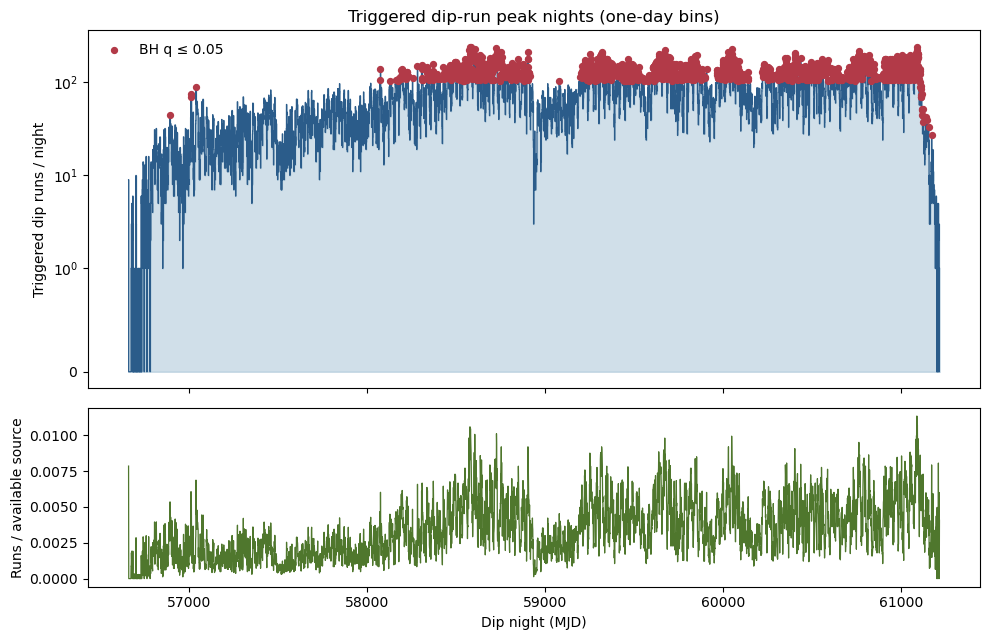

In [5]:
night_summary = summarize_nights(events, all_candidates=candidates)
write_frame(night_summary, "night_summary.csv")
display(night_summary.sort_values(first_column(night_summary, ["count", "event_count", "n_events", "n_dips"]) or night_summary.columns[0], ascending=False).head(25))

night_col = first_column(night_summary, ["dip_night_mjd", "dip_night", "night_mjd", "night"])
night_count_col = first_column(night_summary, ["count", "event_count", "n_events", "n_dips", "trigger_count"])
night_rate_col = first_column(night_summary, ["rate", "trigger_rate", "event_rate", "dip_rate"])
night_q_col = first_column(night_summary, ["qvalue", "q_value", "poisson_qvalue", "poisson_q_value"])
if night_col is None or night_count_col is None:
    raise KeyError(f"Unexpected night-summary schema: {list(night_summary.columns)}")

night_plot = night_summary.sort_values(night_col).copy()
x_night = finite_numeric(night_plot[night_col])
y_count = finite_numeric(night_plot[night_count_col]).fillna(0)
fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True, gridspec_kw={"height_ratios": [2.0, 1.0]})
axes[0].step(x_night, y_count, where="mid", color="#2b5c8a", linewidth=0.9)
axes[0].fill_between(x_night, y_count, step="mid", color="#7aa6c2", alpha=0.35)
if night_q_col is not None:
    q = finite_numeric(night_plot[night_q_col])
    flagged_nights = q.le(0.05)
    axes[0].scatter(x_night[flagged_nights], y_count[flagged_nights], s=18, color="#b23a48", label="BH q ≤ 0.05", zorder=3)
    if flagged_nights.any():
        axes[0].legend(frameon=False)
axes[0].set_ylabel("Triggered dip runs / night")
axes[0].set_yscale("symlog", linthresh=1)
axes[0].set_title("Triggered dip-run peak nights (one-day bins)")
if night_rate_col is not None and finite_numeric(night_plot[night_rate_col]).notna().any():
    axes[1].plot(x_night, finite_numeric(night_plot[night_rate_col]), color="#4f772d", linewidth=0.9)
    axes[1].set_ylabel("Runs / available source")
else:
    axes[1].text(0.5, 0.5, "No exposure-normalized rate available", ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_yticks([])
axes[1].set_xlabel("Dip night (MJD)")
finish_figure(fig, "dip_night_histogram")


## Physical distance versus dip epoch

A global correlation can be induced by seasonal sky coverage, and repeated runs from one source are not independent. The reported p-value therefore permutes each source's distance label as a block within field/camera strata while leaving its complete run schedule intact. The raw Spearman coefficient is retained only as a descriptive effect size.


,n_events,n_sources,spearman_rho,permutation_pvalue,null_mean_rho,null_std_rho,null_q025_rho,null_q975_rho,z_score,n_permutations,strata,n_strata,n_permutable_sources,permutation_unit
0,253763,14856,0.050244,0.004975,0.039074,0.001718,0.03589,0.042557,6.502008,200,asassn_field_key+camera_name_key,4939,12275,source_distance_block


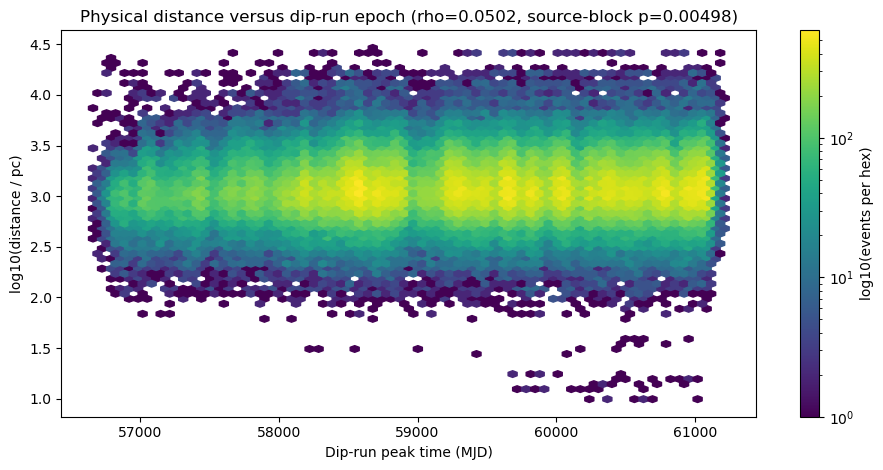

In [6]:
distance_test = distance_time_source_block_permutation_test(
    events,
    strata=("asassn_field_key", "camera_name_key"),
    n_permutations=N_PERMUTATIONS,
    random_state=RANDOM_STATE,
)
display(distance_test)
write_frame(distance_test, "distance_time_permutation_test.csv")

distance_plot = events[["dip_mjd", "distance_pc"]].copy()
distance_plot["dip_mjd"] = finite_numeric(distance_plot["dip_mjd"])
distance_plot["distance_pc"] = finite_numeric(distance_plot["distance_pc"])
distance_plot = distance_plot.dropna().query("distance_pc > 0")
fig, ax = plt.subplots(figsize=(9.5, 4.8))
if not distance_plot.empty:
    density = ax.hexbin(
        distance_plot["dip_mjd"],
        np.log10(distance_plot["distance_pc"]),
        gridsize=(70, 35),
        mincnt=1,
        bins="log",
        cmap="viridis",
    )
    fig.colorbar(density, ax=ax, label="log10(events per hex)")
rho = scalar_from_table(distance_test, ("spearman_rho", "rho"))
p_perm = scalar_from_table(distance_test, ("permutation_pvalue", "permutation_p_value", "pvalue"))
ax.set_title(f"Physical distance versus dip-run epoch (rho={rho:.3g}, source-block p={p_perm:.3g})")
ax.set_xlabel("Dip-run peak time (MJD)")
ax.set_ylabel("log10(distance / pc)")
finish_figure(fig, "physical_distance_vs_dip_time")


## Nearby angular pairs versus dip-time lag

Only runs belonging to different sources within `PAIR_MAX_SEP_DEG` are paired. Time separation is the edge-to-edge gap between the two full run intervals (zero means overlap), while peak-to-peak lag is retained separately. The null swaps complete source run schedules within field/camera strata, preserving recurrence within each source.


,angular_max_deg,lag_max_days,observed_pairs,null_mean_pairs,null_std_pairs,excess_pairs,excess_ratio,z_score,pvalue,qvalue,n_permutations,strata,n_strata,n_sources,n_runs,n_spatial_source_pairs,permutation_unit
0,0.10,0.5,2156,1905.880,90.188109,250.120,1.131236,2.773315,0.009950,0.021322,200,asassn_field_key+camera_name_key,5576,19866,335360,174072,source_run_schedule_block
1,0.10,1.0,2243,2003.695,94.451083,239.305,1.119432,2.533640,0.014925,0.027985,200,asassn_field_key+camera_name_key,5576,19866,335360,174072,source_run_schedule_block
2,0.10,7.0,3144,3034.670,140.055126,109.330,1.036027,0.780621,0.213930,0.213930,200,asassn_field_key+camera_name_key,5576,19866,335360,174072,source_run_schedule_block
3,0.25,0.5,9472,9238.275,217.087504,233.725,1.025300,1.076640,0.149254,0.159915,200,asassn_field_key+camera_name_key,5576,19866,335360,174072,source_run_schedule_block
4,0.25,1.0,10030,9789.405,229.398188,240.595,1.024577,1.048810,0.144279,0.159915,200,asassn_field_key+camera_name_key,5576,19866,335360,174072,source_run_schedule_block
5,0.25,7.0,15738,15341.200,367.416336,396.800,1.025865,1.079974,0.124378,0.155473,200,asassn_field_key+camera_name_key,5576,19866,335360,174072,source_run_schedule_block
6,0.50,0.5,35163,34262.410,442.820973,900.590,1.026285,2.033756,0.034826,0.047490,200,asassn_field_key+camera_name_key,5576,19866,335360,174072,source_run_schedule_block
7,0.50,1.0,37440,36385.530,465.026815,1054.470,1.028980,2.267547,0.019900,0.033167,200,asassn_field_key+camera_name_key,5576,19866,335360,174072,source_run_schedule_block
8,0.50,7.0,60270,57627.225,762.347396,2642.775,1.045860,3.466628,0.004975,0.014925,200,asassn_field_key+camera_name_key,5576,19866,335360,174072,source_run_schedule_block
9,1.00,0.5,129166,127431.600,807.005788,1734.400,1.013610,2.149179,0.029851,0.044776,200,asassn_field_key+camera_name_key,5576,19866,335360,174072,source_run_schedule_block


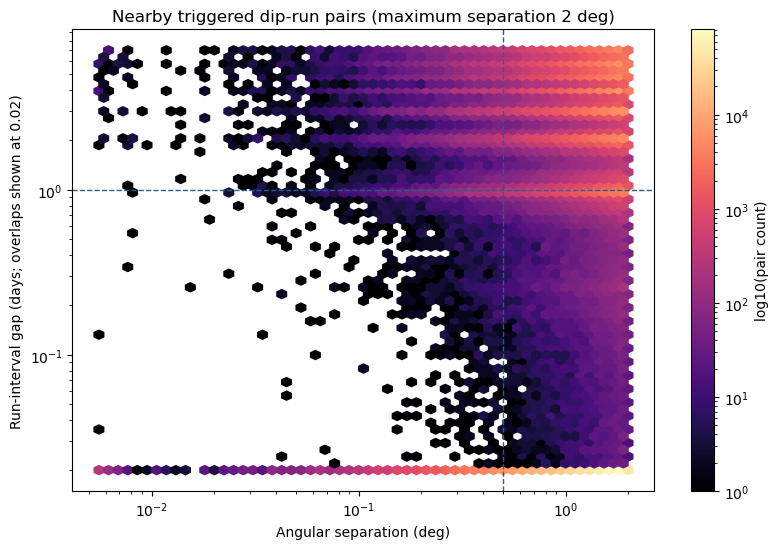

In [7]:
nearby_pairs = build_nearby_run_pairs(
    events,
    max_sep_deg=PAIR_MAX_SEP_DEG,
    max_interval_gap_days=max(PAIR_LAG_THRESHOLDS_DAYS),
)
pair_summary = summarize_run_pair_excess(
    events,
    angular_bins_deg=PAIR_ANGULAR_BINS_DEG,
    lag_thresholds_days=PAIR_LAG_THRESHOLDS_DAYS,
    strata=("asassn_field_key", "camera_name_key"),
    n_permutations=N_PERMUTATIONS,
    random_state=RANDOM_STATE,
)
display(pair_summary)
write_frame(pair_summary, "spatiotemporal_pair_summary.parquet")
if WRITE_FULL_PAIR_TABLE:
    write_frame(nearby_pairs, "nearby_pairs.parquet")

fig, ax = plt.subplots(figsize=(8.2, 5.6))
if not nearby_pairs.empty:
    sep = finite_numeric(nearby_pairs["angular_sep_deg"])
    lag = finite_numeric(nearby_pairs["time_lag_days"])
    valid_pair_plot = sep.gt(0) & lag.notna()
    pair_density = ax.hexbin(
        sep[valid_pair_plot],
        np.maximum(lag[valid_pair_plot], 0.02),
        xscale="log",
        yscale="log",
        gridsize=55,
        mincnt=1,
        bins="log",
        cmap="magma",
    )
    fig.colorbar(pair_density, ax=ax, label="log10(pair count)")
ax.axvline(FLAG_ANGULAR_DEG, color="#2b5c8a", linestyle="--", linewidth=1.0)
ax.axhline(FLAG_LAG_DAYS, color="#2b5c8a", linestyle="--", linewidth=1.0)
ax.set_xlabel("Angular separation (deg)")
ax.set_ylabel("Run-interval gap (days; overlaps shown at 0.02)")
ax.set_title(f"Nearby triggered dip-run pairs (maximum separation {PAIR_MAX_SEP_DEG:g} deg)")
finish_figure(fig, "angular_separation_vs_time_lag")


## Triggered-run rates by actual field and camera

Each run is attributed from its actual paired trigger field/camera samples. Rates use detector-valid observations from all 22,942 review candidates as the denominator, so a group is compared by runs per 1,000 usable observations rather than by the fraction of sources whose modal label happened to match it. This is candidate-cohort exposure normalization, not a survey-wide trigger probability; Poisson q-values remain exploratory.


field: 2,613 groups


,asassn_field_key,n_observations,n_observed_nights,n_available_sources,n_runs,n_trigger_points,n_triggered_sources,runs_per_1000_observations,trigger_points_per_1000_observations,runs_per_available_source,expected_runs_from_observations,pvalue_run_overdensity,qvalue_run_overdensity,rate_error_per_1000_observations
428,F1138-62_2589,146167,145372,117,2052,6276,105,14.038737,42.937188,17.538462,1446.074294,5.575054e-51,1.456762e-47,0.309913
308,F0819-30_2009,83164,82801,63,1282,3963,52,15.415324,47.652831,20.349206,822.766579,1.013598e-49,1.324265e-46,0.430535
113,F0048+62_1131,27310,27310,36,536,1591,32,19.626510,58.257049,14.888889,270.186081,3.309423e-46,2.882507e-43,0.847736
216,F2223+54_1119,49231,49231,60,828,2154,53,16.818671,43.752920,13.800000,487.057158,6.054277e-45,3.954957e-42,0.584489
384,F1557-54_2497,103049,102875,81,1490,4271,66,14.459141,41.446302,18.395062,1019.494892,1.981089e-43,1.035317e-40,0.374584
76,F1354-78_2757,18622,18479,17,395,1259,15,21.211470,67.608205,23.235294,184.233072,1.874134e-41,8.161855e-39,1.067265
436,F0729-14_1652,110013,109468,90,1539,4156,78,13.989256,37.777354,17.100000,1088.391848,4.868090e-38,1.817188e-35,0.356595
372,F0724-22_1829,83705,83394,58,1222,3499,49,14.598889,41.801565,21.068966,828.118856,1.304395e-37,4.260480e-35,0.417623
147,F2214+58_1224,27290,27290,42,504,1426,37,18.468303,52.253573,12.000000,269.988215,3.832912e-37,1.112822e-34,0.822644
189,F0641-14_1645,32016,31972,24,558,1653,22,17.428786,51.630435,23.250000,316.743961,1.376894e-34,3.597824e-32,0.737819


camera: 29 groups


,camera_name_key,n_observations,n_observed_nights,n_available_sources,n_runs,n_trigger_points,n_triggered_sources,runs_per_1000_observations,trigger_points_per_1000_observations,runs_per_available_source,expected_runs_from_observations,pvalue_run_overdensity,qvalue_run_overdensity,rate_error_per_1000_observations
0,bB,467507,467507,4143,8596,27451,2561,18.386890,58.717837,2.074825,4625.188004,0.000000e+00,0.000000e+00,0.198317
1,bC,1176913,1176710,3887,20863,63550,2892,17.726884,53.997194,5.367378,11643.555902,0.000000e+00,0.000000e+00,0.122728
2,bA,1088599,1088577,3997,18541,58446,2912,17.031983,53.689191,4.638729,10769.838817,0.000000e+00,0.000000e+00,0.125083
3,bE,1912281,1906645,6171,28952,85172,3891,15.140034,44.539479,4.691622,18918.773711,0.000000e+00,0.000000e+00,0.088979
4,bD,1202896,1202813,3951,18143,57953,2715,15.082767,48.177897,4.592002,11900.613572,0.000000e+00,0.000000e+00,0.111976
5,bF,1774493,1770071,6122,23692,68169,3919,13.351419,38.416043,3.869977,17555.595395,0.000000e+00,0.000000e+00,0.086741
6,bH,1578960,1574636,5739,21069,60526,3432,13.343593,38.332827,3.671197,15621.128348,0.000000e+00,0.000000e+00,0.091929
7,bG,1607784,1585804,5440,21411,59880,3267,13.317087,37.243809,3.935846,15906.292889,0.000000e+00,0.000000e+00,0.091010
9,bc,723944,723928,3998,7947,21107,2239,10.977368,29.155570,1.987744,7162.196725,4.213598e-20,1.357715e-19,0.123139
8,cB,397662,397632,3457,4424,15270,1694,11.125026,38.399445,1.279722,3934.190316,1.006093e-14,2.917671e-14,0.167261


camera_field: 14,181 groups


,asassn_field_key,camera_name_key,n_observations,n_observed_nights,n_available_sources,n_runs,n_trigger_points,n_triggered_sources,runs_per_1000_observations,trigger_points_per_1000_observations,runs_per_available_source,expected_runs_from_observations,pvalue_run_overdensity,qvalue_run_overdensity,rate_error_per_1000_observations
1499,F1138-62_2589,bE,47656,47625,112,954,3046,94,20.018466,63.916401,8.517857,471.475207,9.009718e-85,1.277668e-80,0.648122
1207,F1557-54_2497,bE,35327,35315,78,769,2399,60,21.768053,67.908399,9.858974,349.500685,1.740431e-83,1.234053e-79,0.784976
958,F0819-30_2009,bE,26209,26063,57,621,1786,46,23.694151,68.144531,10.894737,259.293556,9.551608e-81,4.515045e-77,0.950814
904,F2223+54_1119,bC,19372,19372,56,468,1183,50,24.158579,61.067520,8.357143,191.653049,1.126371e-63,3.993266e-60,1.116731
1158,F0729-14_1652,bF,23341,23265,77,516,1323,67,22.107022,56.681376,6.701299,230.919565,1.343777e-58,3.811220e-55,0.973207
1457,F0837-46_2325,bE,25422,25422,52,515,1538,37,20.258044,60.498781,9.903846,251.507527,4.685804e-48,1.107490e-44,0.892676
1344,F0756-22_1833,bE,22623,22617,62,471,1385,49,20.819520,61.220881,7.596774,223.816174,5.004481e-47,7.885393e-44,0.959313
1156,F0801-38_2172,bF,18529,18529,33,410,1100,30,22.127476,59.366399,12.424242,183.312995,4.645432e-47,7.885393e-44,1.092798
1001,F1343-58_2599,bG,15613,15577,38,365,971,33,23.377954,62.191763,9.605263,154.464126,4.752216e-47,7.885393e-44,1.223658
1885,F1329-62_2597,bE,34734,34667,79,637,1862,60,18.339379,53.607416,8.063291,343.633957,1.575562e-45,2.234304e-42,0.726633


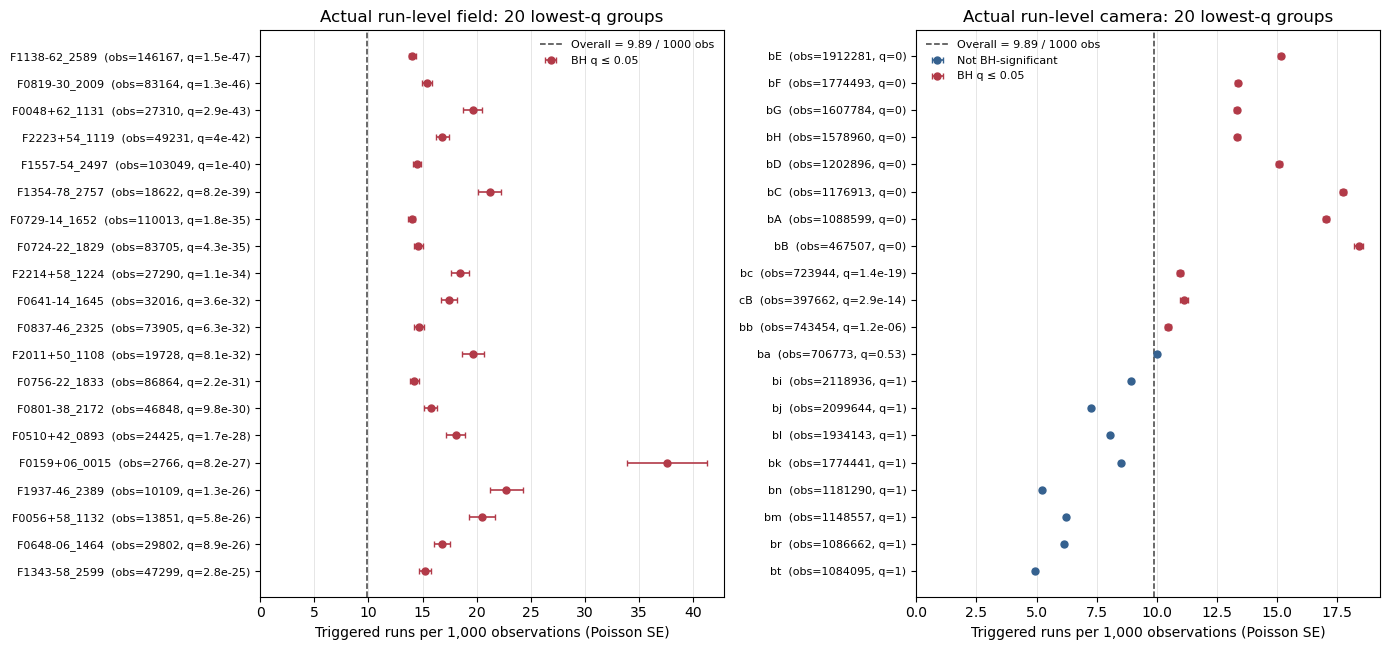

In [8]:
group_rate_tables = triggered_run_group_rates(
    events,
    run_exposures,
    group_cols=("asassn_field_key", "camera_name_key"),
)
field_camera_rates = pd.concat(
    [table.assign(grouping=name) for name, table in group_rate_tables.items()],
    ignore_index=True,
) if group_rate_tables else pd.DataFrame()
write_frame(field_camera_rates, "field_camera_run_rates.csv")

for name, table in group_rate_tables.items():
    print(f"{name}: {len(table):,} groups")
    q_col = first_column(table, ["qvalue_run_overdensity", "qvalue", "q_value"])
    display(table.sort_values(q_col, ascending=True).head(15) if q_col else table.head(15))

overall_run_rate = 1000.0 * len(events) / pd.to_numeric(run_exposures["n_observations"], errors="coerce").sum()
plot_items = [(name, table) for name, table in group_rate_tables.items() if name in {"field", "camera"} and not table.empty]
if plot_items:
    fig, axes = plt.subplots(1, len(plot_items), figsize=(7.0 * len(plot_items), 6.6), squeeze=False)
    for ax, (name, table) in zip(axes[0], plot_items):
        rate_col = first_column(table, ["runs_per_1000_observations", "run_rate", "rate"])
        count_col = first_column(table, ["n_observations", "observation_count", "count"])
        label_col = first_column(table, ["asassn_field_key", "camera_name_key", "field", "camera"])
        error_col = first_column(table, ["rate_error_per_1000_observations", "rate_error"])
        q_col = first_column(table, ["qvalue_run_overdensity", "qvalue", "q_value"])
        required_schema = {"rate": rate_col, "count": count_col, "label": label_col, "error": error_col, "qvalue": q_col}
        if any(column is None for column in required_schema.values()):
            ax.text(0.5, 0.5, f"Unexpected {name} schema", ha="center", va="center", transform=ax.transAxes)
            ax.text(0.5, 0.42, str(required_schema), ha="center", va="center", fontsize=8, transform=ax.transAxes)
            continue
        ranked = table.copy()
        for column in (rate_col, count_col, error_col, q_col):
            ranked[column] = finite_numeric(ranked[column])
        ranked = ranked[ranked[count_col].ge(100)].dropna(subset=[rate_col, error_col, q_col, label_col])
        ranked = ranked.sort_values([q_col, count_col], ascending=[True, False], kind="mergesort").head(20)
        ranked = ranked.sort_values([q_col, count_col], ascending=[False, True], kind="mergesort").reset_index(drop=True)
        if ranked.empty:
            ax.text(0.5, 0.5, f"No {name} groups with at least 100 observations", ha="center", va="center", transform=ax.transAxes)
            continue
        y = np.arange(len(ranked))
        legend_seen: set[str] = set()
        for position, (_, row) in enumerate(ranked.iterrows()):
            is_significant = bool(row[q_col] <= 0.05)
            color = "#b23a48" if is_significant else "#35618f"
            legend_label = "BH q ≤ 0.05" if is_significant else "Not BH-significant"
            show_label = legend_label if legend_label not in legend_seen else None
            legend_seen.add(legend_label)
            rate = float(row[rate_col])
            ax.errorbar(rate, position, xerr=float(row[error_col]), fmt="o", color=color, ecolor=color, markersize=5, elinewidth=1.2, capsize=2.5, label=show_label, zorder=3)
        ax.axvline(overall_run_rate, color="0.25", linestyle="--", linewidth=1.1, label=f"Overall = {overall_run_rate:.3g} / 1000 obs")
        labels = [f"{row[label_col]}  (obs={int(row[count_col])}, q={row[q_col]:.2g})" for _, row in ranked.iterrows()]
        ax.set_yticks(y, labels=labels, fontsize=8)
        ax.set_xlim(left=0)
        ax.set_xlabel("Triggered runs per 1,000 observations (Poisson SE)")
        ax.set_title(f"Actual run-level {name}: 20 lowest-q groups")
        ax.legend(frameon=False, fontsize=8, loc="best")
        ax.grid(axis="x", color="0.9", linewidth=0.7)
    finish_figure(fig, "run_field_camera_trigger_rates")


## Flag close pairs and assemble connected clusters

The fixed audit window below is intentionally transparent. Connected components merge pairs sharing a run into run-level systematic clusters. A recurring source may contribute several distinct runs; `n_sources` is reported separately. This creates a review queue, not an instrumental classification.


In [9]:
pair_left_col = "event_id_i"
pair_right_col = "event_id_j"
if pair_left_col is None or pair_right_col is None:
    raise KeyError(f"Could not identify pair source columns: {list(nearby_pairs.columns)}")

flag_mask = (
    finite_numeric(nearby_pairs["angular_sep_deg"]).le(FLAG_ANGULAR_DEG)
    & finite_numeric(nearby_pairs["time_lag_days"]).le(FLAG_LAG_DAYS)
)
flagged_pairs = nearby_pairs.loc[flag_mask].copy()
flagged_pairs["proximity_score"] = (
    finite_numeric(flagged_pairs["angular_sep_deg"]) / FLAG_ANGULAR_DEG
    + finite_numeric(flagged_pairs["time_lag_days"]) / FLAG_LAG_DAYS
)
flagged_pairs = flagged_pairs.sort_values(["proximity_score", "angular_sep_deg", "time_lag_days"]).reset_index(drop=True)

parent: dict[str, str] = {}


def find_root(item: str) -> str:
    parent.setdefault(item, item)
    while parent[item] != item:
        parent[item] = parent[parent[item]]
        item = parent[item]
    return item


def union(left: str, right: str) -> None:
    root_left, root_right = find_root(left), find_root(right)
    if root_left != root_right:
        parent[root_right] = root_left


for left, right in flagged_pairs[[pair_left_col, pair_right_col]].itertuples(index=False, name=None):
    union(str(left), str(right))
components: dict[str, list[str]] = {}
for run_id in parent:
    components.setdefault(find_root(run_id), []).append(run_id)
ordered_components = sorted(components.values(), key=lambda members: (-len(members), sorted(members)))
run_to_cluster = {run_id: f"cluster_{index:04d}" for index, members in enumerate(ordered_components, start=1) for run_id in members}
if not flagged_pairs.empty:
    flagged_pairs["cluster_id"] = flagged_pairs[pair_left_col].astype(str).map(run_to_cluster)

cluster_rows = []
event_by_id = events.set_index(events["event_id"].astype(str), drop=False)
for index, members in enumerate(ordered_components, start=1):
    cluster_id = f"cluster_{index:04d}"
    edges = flagged_pairs[flagged_pairs.get("cluster_id", pd.Series(index=flagged_pairs.index, dtype=str)).eq(cluster_id)]
    member_events = event_by_id.loc[event_by_id.index.intersection(members)]
    nights = sorted(set(finite_numeric(member_events.get("dip_night_mjd", pd.Series(dtype=float))).dropna().astype(int)))
    cluster_rows.append(
        {
            "cluster_id": cluster_id,
            "n_runs": len(members),
            "n_sources": int(member_events["source_key"].nunique()),
            "n_flagged_pairs": len(edges),
            "event_ids": "|".join(sorted(members)),
            "source_keys": "|".join(sorted(member_events["source_key"].astype(str).unique())),
            "dip_nights_mjd": "|".join(map(str, nights)),
            "min_angular_sep_deg": safe_min(edges, ("angular_sep_deg",)),
            "max_time_lag_days": float(finite_numeric(edges["time_lag_days"]).max()) if not edges.empty else np.nan,
            "same_field_fraction": float(pd.to_numeric(edges.get("same_field"), errors="coerce").mean()) if "same_field" in edges else np.nan,
            "same_camera_fraction": float(pd.to_numeric(edges.get("same_camera"), errors="coerce").mean()) if "same_camera" in edges else np.nan,
        }
    )
cluster_summary = pd.DataFrame(
    cluster_rows,
    columns=["cluster_id", "n_runs", "n_sources", "n_flagged_pairs", "event_ids", "source_keys", "dip_nights_mjd", "min_angular_sep_deg", "max_time_lag_days", "same_field_fraction", "same_camera_fraction"],
)
display(flagged_pairs.head(50))
display(cluster_summary.head(50))
write_frame(flagged_pairs, "flagged_pair_table.parquet")
write_frame(cluster_summary, "flagged_systematic_clusters.csv")


,event_id_i,event_id_j,event_row_i,event_row_j,source_i,source_j,angular_sep_deg,time_lag_days,peak_time_lag_days,intervals_overlap,field_i,field_j,same_field,camera_i,camera_j,same_camera,proximity_score,cluster_id
0,stv_420907553024:dip_run_0004,stv_420907553023:dip_run_0003,78540,78539,stv_420907553024,stv_420907553023,0.005570,0.0,0.000000,True,F0845-50_2462,F0845-50_2462,True,bH,bH,True,0.011139,cluster_15407
1,stv_420907553024:dip_run_0003,stv_420907553023:dip_run_0002,74033,74043,stv_420907553024,stv_420907553023,0.005570,0.0,0.081292,True,F0845-50_2462,F0845-50_2462,True,bH,bH,True,0.011139,cluster_15406
2,stv_420907553024:dip_run_0013,stv_420907553023:dip_run_0007,281778,281749,stv_420907553024,stv_420907553023,0.005570,0.0,0.199445,True,F0845-50_2462,F0845-50_2462,True,bH,bH,True,0.011139,cluster_15410
3,stv_420907553024:dip_run_0014,stv_420907553023:dip_run_0008,289123,289018,stv_420907553024,stv_420907553023,0.005570,0.0,0.296637,True,F0845-50_2462,F0845-50_2462,True,bl,bl,True,0.011139,cluster_15411
4,stv_420907553024:dip_run_0012,stv_420907553023:dip_run_0006,242393,242320,stv_420907553024,stv_420907553023,0.005570,0.0,0.482967,True,F0845-50_2462,F0845-50_2462,True,bl,bl,True,0.011139,cluster_15409
5,stv_420907553024:dip_run_0006,stv_420907553023:dip_run_0004,148145,148517,stv_420907553024,stv_420907553023,0.005570,0.0,3.832126,True,F0845-50_2462,F0845-50_2462,True,bH,bH,True,0.011139,cluster_15408
6,stv_644246104644:dip_run_0005,stv_644246104606:dip_run_0003,62023,62025,stv_644246104644,stv_644246104606,0.005585,0.0,0.002937,True,F1557-54_2497,F1557-54_2497,True,bi,be,False,0.011169,cluster_0046
7,stv_644246104644:dip_run_0023,stv_644246104606:dip_run_0010,261059,261060,stv_644246104644,stv_644246104606,0.005585,0.0,0.005587,True,F1557-54_2497,F1557-54_2497,True,bE,bE,True,0.011169,cluster_0260
8,stv_644246104644:dip_run_0022,stv_644246104606:dip_run_0009,251801,251792,stv_644246104644,stv_644246104606,0.005585,0.0,0.014709,True,F1557-54_2497,F1557-54_2497,True,bE,bE,True,0.011169,cluster_1944
9,stv_644246104644:dip_run_0031,stv_644246104606:dip_run_0012,295849,295890,stv_644246104644,stv_644246104606,0.005585,0.0,0.095380,True,F1557-54_2497,F1557-54_2497,True,bi,bi,True,0.011169,cluster_1946


,cluster_id,n_runs,n_sources,n_flagged_pairs,event_ids,source_keys,dip_nights_mjd,min_angular_sep_deg,max_time_lag_days,same_field_fraction,same_camera_fraction
0,cluster_0001,165,41,224,stv_369368415302:dip_run_0004|stv_369368415302...,stv_369368415302|stv_481036510257|stv_51539667...,59306|59309|59310|59317|59319|59324|59325|5932...,0.033000,0.98808,0.705357,0.375000
1,cluster_0002,93,43,141,stv_515396676109:dip_run_0032|stv_515396676109...,stv_515396676109|stv_515397124907|stv_51539718...,60212|60261|60268|60271|60272|60274|60277|6028...,0.067599,0.96068,0.794326,0.375887
2,cluster_0003,80,15,385,stv_584116520244:dip_run_0022|stv_584116520244...,stv_584116520244|stv_592705934726|stv_62706624...,58586|58588|58595|58597|58600|58601|58604|5860...,0.029800,0.99358,0.633766,0.519481
3,cluster_0004,47,14,70,stv_566936356336:dip_run_0006|stv_566936356336...,stv_566936356336|stv_584116650800|stv_59270565...,60339|60340|60347|60358|60360|60362|60377|6038...,0.101872,0.98633,0.457143,0.242857
4,cluster_0005,40,24,51,stv_369368415302:dip_run_0008|stv_369368415302...,stv_369368415302|stv_515396676109|stv_51539712...,59739|59750|59759|59773|59784|59795|59804|5980...,0.033777,0.98984,0.549020,0.254902
5,cluster_0006,34,16,49,stv_317828392116:dip_run_0015|stv_343597467146...,stv_317828392116|stv_343597467146|stv_38654732...,60418|60424|60426|60427|60431|60442|60444|6044...,0.125071,0.00000,1.000000,0.448980
6,cluster_0007,33,13,38,stv_584116650800:dip_run_0012|stv_592705652886...,stv_584116650800|stv_592705652886|stv_59270602...,59250|59256|59261|59270|59283|59288|59295|5929...,0.183263,0.98293,0.842105,0.342105
7,cluster_0008,31,11,40,stv_120260537941:dip_run_0006|stv_120260537941...,stv_120260537941|stv_163208871937|stv_16320889...,58572|58615|58658|58697|58735|58745|58751|5875...,0.130451,0.98735,0.900000,0.650000
8,cluster_0009,30,12,42,stv_584116650800:dip_run_0017|stv_584116650800...,stv_584116650800|stv_592705652886|stv_59270633...,59963|59966|59972|59994|60001|60002|60003|6000...,0.101872,0.93790,0.380952,0.238095
9,cluster_0010,25,5,27,stv_257698240275:dip_run_0015|stv_377958030389...,stv_257698240275|stv_377958030389|stv_39513757...,59509|59511|59522|59523|59546|59550|59553|5956...,0.297402,0.09994,0.555556,0.259259


PosixPath('/Users/calder/code/malca/output/notebooks/july1_triggered_dip_systematics/flagged_systematic_clusters.csv')

## Exact run attribution and replay exposure

The historical replay already records the field and camera of the trigger samples for every run, together with observation exposure by source and group. No approximate best-dip window scan is needed. Multi-valued trigger attribution is retained in JSON columns; the scalar field/camera keys are the run's modal trigger groups.


In [10]:
event_attribution = events[[column for column in (
    "event_id", "source_key", "run_number", "run_start_jd", "run_end_jd",
    "dip_jd", "dip_night_mjd", "asassn_field_key", "camera_name_key",
    "trigger_jds_json", "trigger_fields_json", "trigger_cameras_json", "n_trigger_points",
) if column in events.columns]].copy()
display(event_attribution.head(20))
display(run_exposures.head(20))


,event_id,source_key,run_number,run_start_jd,run_end_jd,dip_jd,dip_night_mjd,asassn_field_key,camera_name_key,trigger_jds_json,trigger_fields_json,trigger_cameras_json,n_trigger_points
0,stv_377957474869:dip_run_0001,stv_377957474869,1,2.456659e+06,2.456759e+06,2.456659e+06,56658,F0751-06_1472,bb,"[2456658.85782,2456758.75394]","[""F0751-06_1472"",""F0751-06_1472""]","[""bb"",""bb""]",2
1,stv_249108300210:dip_run_0001,stv_249108300210,1,2.456659e+06,2.456659e+06,2.456659e+06,56658,F0943+22_0435,bc,"[2456658.87979,2456658.90118]","[""F0943+22_0435"",""F0951+18_0436""]","[""bc"",""bb""]",2
2,stv_292057924584:dip_run_0001,stv_292057924584,1,2.456659e+06,2.456742e+06,2.456659e+06,56658,F0910-06_1481,ba,"[2456658.88503,2456741.83906]","[""F0910-06_1481"",""F0910-06_1481""]","[""ba"",""ba""]",2
3,stv_197569314737:dip_run_0001,stv_197569314737,1,2.456659e+06,2.456731e+06,2.456659e+06,56658,F0538+06_0043,bc,"[2456658.89152,2456677.87027,2456730.77069]","[""F0538+06_0043"",""F0538+06_0043"",""F0538+06_0043""]","[""bc"",""bc"",""bc""]",3
4,stv_197569349203:dip_run_0001,stv_197569349203,1,2.456659e+06,2.456679e+06,2.456659e+06,56658,F0538+06_0043,bc,"[2456658.89152,2456678.87274]","[""F0538+06_0043"",""F0538+06_0043""]","[""bc"",""bc""]",2
5,stv_25769963836:dip_run_0001,stv_25769963836,1,2.456659e+06,2.456737e+06,2.456659e+06,56658,F0725+58_1160,bb,"[2456658.92839,2456736.7491]","[""F0725+58_1160"",""F0725+58_1160""]","[""bb"",""bb""]",2
6,stv_309238014314:dip_run_0001,stv_309238014314,1,2.456659e+06,2.456753e+06,2.456659e+06,56658,F1218-06_1505,ba,"[2456659.05144,2456752.87129]","[""F1218-06_1505"",""F1218-06_1505""]","[""ba"",""ba""]",2
7,stv_128850416761:dip_run_0001,stv_128850416761,1,2.456659e+06,2.456772e+06,2.456659e+06,56658,F1545+58_1196,bb,"[2456659.12319,2456736.99131,2456772.09786]","[""F1545+58_1196"",""F1545+58_1196"",""F1545+58_1196""]","[""bb"",""bb"",""bb""]",3
8,stv_498216929369:dip_run_0001,stv_498216929369,1,2.456659e+06,2.456659e+06,2.456659e+06,56658,F1419-30_2052,bb,"[2456659.14163,2456659.14189]","[""F1437-30_2053"",""F1419-30_2052""]","[""ba"",""bb""]",2
9,stv_566936811481:dip_run_0001,stv_566936811481,1,2.456659e+06,2.456683e+06,2.456673e+06,56672,F1037-30_2025,ba,"[2456659.01169,2456682.93757]","[""F1037-30_2025"",""F1037-30_2025""]","[""ba"",""ba""]",2


,candidate_id,source_key,camera_name_key,asassn_field_key,n_observations,n_observed_nights,first_reduced_jd,last_reduced_jd
0,stv_1010965,stv_1010965,bG,F1044-81_2799,488,488,8419.85792,11110.51958
1,stv_1010965,stv_1010965,bH,F1136-82_2802,320,320,8467.84590,11115.89270
2,stv_1010965,stv_1010965,be,F1044-81_2799,79,78,6789.54826,7205.46625
3,stv_1010965,stv_1010965,bf,F0937-85_2800,152,152,7220.46098,8315.46321
4,stv_1010965,stv_1010965,bg,F1044-81_2799,185,183,7318.87753,8243.48334
5,stv_1010965,stv_1010965,bh,F1136-82_2802,154,154,7378.85959,8315.46313
6,stv_1010965,stv_1010965,bl,F1136-82_2802,489,486,8117.81828,11114.57715
7,stv_1010965,stv_1010965,bo,F1044-81_2799,284,280,8127.55171,11104.31027
8,stv_1010965,stv_1010965,bp,F1136-82_2802,218,216,8129.53155,11062.51390
9,stv_1011169,stv_1011169,bF,F0654-85_2796,455,455,8410.87961,11116.72225


## Night × camera and night × field maps

Cells show the number of detector-kept runs whose peak falls on each night, attributed to the actual trigger field or camera. Only the most populated groups and nights are drawn; the exported table retains every row. This map is a count diagnostic because the replay exposure cache is source × group, not night × group.


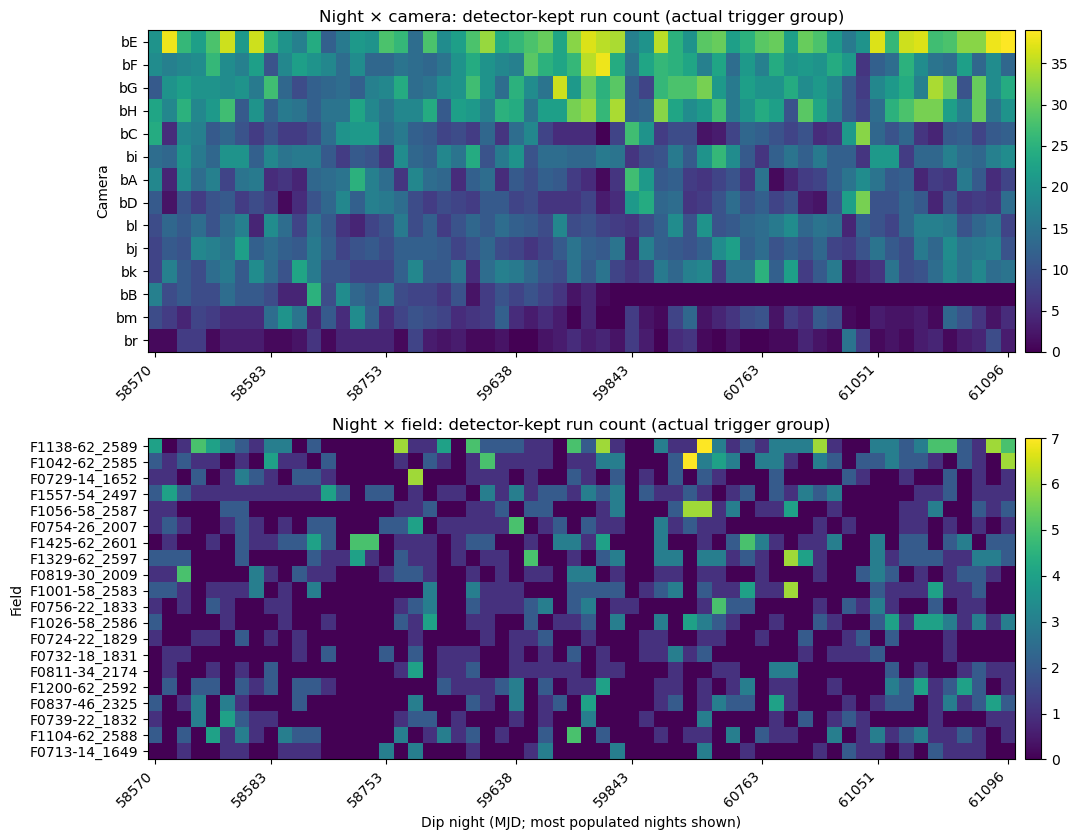

In [11]:
heat_frames = {}
night_group_tables = []
for kind, group_col in (("camera", "camera_name_key"), ("field", "asassn_field_key")):
    frame = (
        events.groupby(["dip_night_mjd", group_col], dropna=False)
        .agg(n_runs=("event_id", "size"), n_sources=("source_key", "nunique"), n_trigger_points=("n_trigger_points", "sum"))
        .reset_index().rename(columns={"dip_night_mjd": "night_mjd", group_col: "group"})
    )
    frame["grouping"] = kind
    heat_frames[kind] = frame
    night_group_tables.append(frame)
night_camera_field_runs = pd.concat(night_group_tables, ignore_index=True)
write_frame(night_camera_field_runs, "night_camera_field_run_counts.csv")
heat_value = "n_runs"
heat_label = "detector-kept run count (actual trigger group)"

fig, axes = plt.subplots(2, 1, figsize=(12, 8.5), squeeze=False)
for ax, kind in zip(axes[:, 0], ("camera", "field")):
    frame = heat_frames.get(kind, pd.DataFrame()).copy()
    if frame.empty or heat_value not in frame:
        ax.text(0.5, 0.5, f"No {kind} heatmap data", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        continue
    frame["group"] = frame["group"].astype("string").fillna("unknown")
    top_groups = frame.groupby("group")[heat_value].sum().nlargest(20).index
    top_nights = frame.groupby("night_mjd")[heat_value].sum().nlargest(60).index
    matrix = frame[frame["group"].isin(top_groups) & frame["night_mjd"].isin(top_nights)].pivot_table(index="group", columns="night_mjd", values=heat_value, aggfunc="sum", fill_value=0)
    matrix = matrix.reindex(index=top_groups.intersection(matrix.index), columns=sorted(matrix.columns))
    image = ax.imshow(matrix.to_numpy(dtype=float), aspect="auto", interpolation="nearest", cmap="viridis")
    ax.set_yticks(np.arange(len(matrix.index)), labels=matrix.index.astype(str))
    tick_positions = np.linspace(0, max(len(matrix.columns) - 1, 0), min(8, len(matrix.columns)), dtype=int) if len(matrix.columns) else []
    ax.set_xticks(tick_positions, labels=[str(int(float(matrix.columns[pos]))) for pos in tick_positions], rotation=45, ha="right")
    ax.set_title(f"Night × {kind}: {heat_label}")
    ax.set_ylabel(kind.title())
    fig.colorbar(image, ax=ax, pad=0.01)
axes[-1, 0].set_xlabel("Dip night (MJD; most populated nights shown)")
finish_figure(fig, "night_camera_field_heatmaps")


## Light-curve panels for every flagged pair

Panels load the read-only bundled light curves, shade each exact run interval, mark its fitted center (or trigger fallback), and highlight the samples that triggered that run. Magnitude axes are inverted. Every flagged run pair remains in `flagged_pair_table.parquet`; the human-readable atlas exports the 500 closest pairs by default because the run-level correction yields tens of thousands of pair rows. Set `MALCA_SYSTEMATICS_MAX_FLAGGED_PAIR_PLOTS=0` only when a deliberately unbounded atlas is wanted.


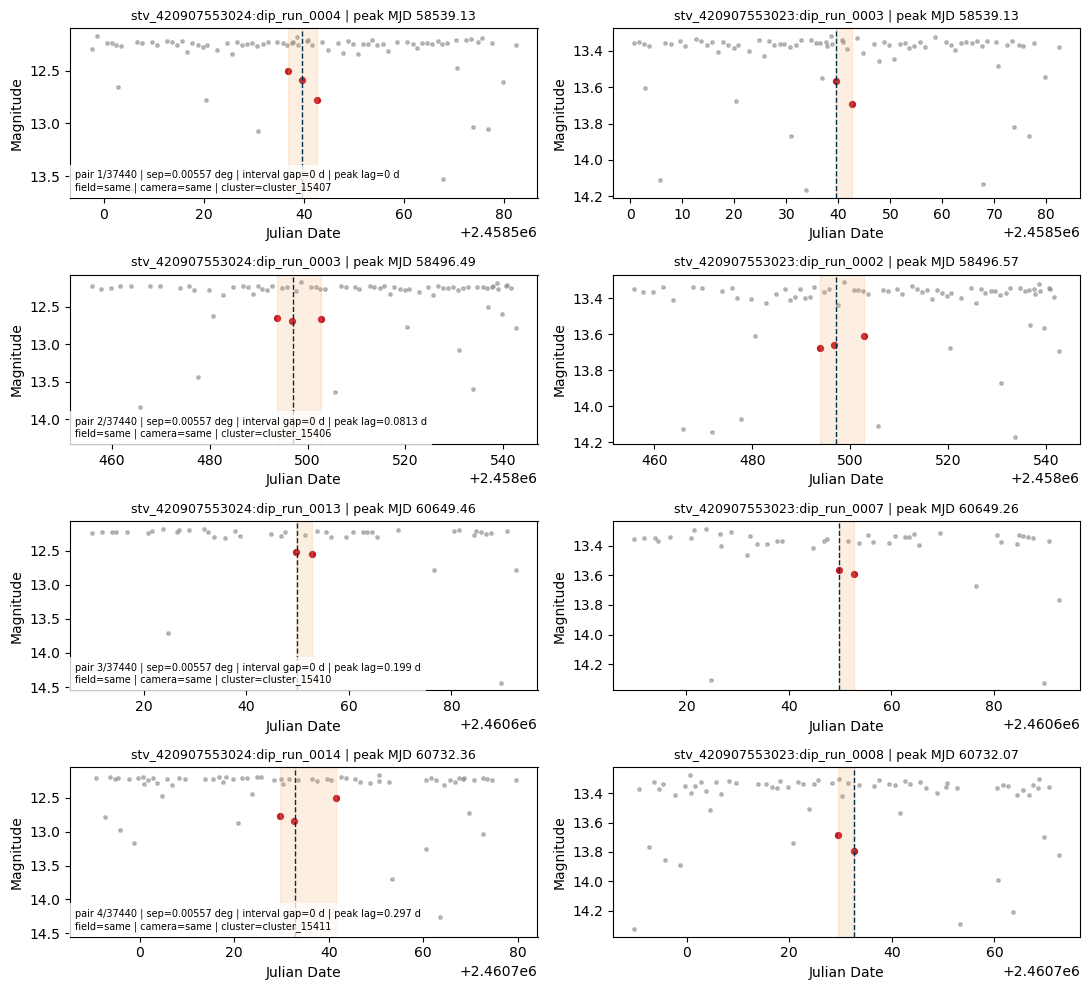

Plotting the first 500 of 37,440 flagged pairs; set MALCA_SYSTEMATICS_MAX_FLAGGED_PAIR_PLOTS=0 for all.
Plotted 500 flagged run pairs across 84 pages.


In [12]:
@lru_cache(maxsize=256)
def cached_lightcurve(path_string: str) -> pd.DataFrame:
    return load_lightcurve_df(Path(path_string), apply_quality=False)


def plot_event_lightcurve(ax: plt.Axes, event_row: pd.Series) -> None:
    source = str(event_row.get("source_key", event_row.get("candidate_id", "unknown")))
    path_value = event_row.get("lc_path", event_row.get("source_path"))
    lc_path = resolve_local_lightcurve_path(path_value, run_dir=RUN_ROOT, repo_root=REPO_ROOT)
    if lc_path is None:
        ax.text(0.5, 0.5, f"{source}\nlight curve unavailable", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return
    lightcurve = cached_lightcurve(str(lc_path))
    if lightcurve.empty:
        ax.text(0.5, 0.5, f"{source}\nno quality-passing points", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return
    time = finite_numeric(lightcurve["jd"])
    mag = finite_numeric(lightcurve["mag"])
    t0 = float(event_row["dip_jd"])
    run_start = float(event_row["run_start_jd"])
    run_end = float(event_row["run_end_jd"])
    window = time.between(run_start - PANEL_HALF_WINDOW_DAYS, run_end + PANEL_HALF_WINDOW_DAYS) & mag.notna()
    if window.sum() < 8:
        window = time.notna() & mag.notna()
    trigger_jds = np.asarray(json.loads(str(event_row.get("trigger_jds_json", "[]"))), dtype=float)
    trigger_mask = np.zeros(len(lightcurve), dtype=bool)
    if trigger_jds.size:
        finite_time = time.notna().to_numpy()
        trigger_mask[finite_time] = np.isclose(time[finite_time].to_numpy()[:, None], trigger_jds[None, :], atol=1e-7, rtol=0).any(axis=1)
    trigger_mask = pd.Series(trigger_mask, index=lightcurve.index) & window
    ax.scatter(time[window & ~trigger_mask], mag[window & ~trigger_mask], s=6, color="0.55", alpha=0.55, rasterized=True)
    ax.scatter(time[trigger_mask], mag[trigger_mask], s=18, color="#c1121f", alpha=0.95, rasterized=True, label="trigger samples")
    ax.axvspan(run_start, run_end, color="#f4a261", alpha=0.18, label="run interval")
    ax.axvline(t0, color="#003049", linewidth=1.0, linestyle="--")
    ax.invert_yaxis()
    ax.set_title(f"{event_row['event_id']} | peak MJD {float(event_row['dip_mjd']):.2f}", fontsize=9)
    ax.set_xlabel("Julian Date")
    ax.set_ylabel("Magnitude")


indexed_events = events.assign(_event_string=events["event_id"].astype(str)).set_index("_event_string", drop=False)


def plot_flagged_pair_row(pair_axes: np.ndarray, pair: pd.Series, *, pair_rank: int) -> None:
    for column_index, pair_source_col in enumerate((pair_left_col, pair_right_col)):
        run_id = str(pair[pair_source_col])
        if run_id in indexed_events.index:
            event_row = indexed_events.loc[run_id]
            plot_event_lightcurve(pair_axes[column_index], event_row)
        else:
            pair_axes[column_index].text(0.5, 0.5, f"Missing run row: {run_id}", ha="center", va="center", transform=pair_axes[column_index].transAxes)
            pair_axes[column_index].set_axis_off()
    same_field = "same" if bool(pair.get("same_field", False)) else "different"
    same_camera = "same" if bool(pair.get("same_camera", False)) else "different"
    cluster = pair.get("cluster_id", pd.NA)
    cluster_text = "NA" if pd.isna(cluster) else str(cluster)
    pair_axes[0].text(
        0.01, 0.03,
        f"pair {pair_rank + 1}/{len(flagged_pairs)} | sep={pair['angular_sep_deg']:.3g} deg | interval gap={pair['time_lag_days']:.3g} d | peak lag={pair['peak_time_lag_days']:.3g} d\n"
        f"field={same_field} | camera={same_camera} | cluster={cluster_text}",
        transform=pair_axes[0].transAxes, fontsize=7.0, va="bottom", linespacing=1.2,
        bbox={"facecolor": "white", "alpha": 0.78, "edgecolor": "none"},
    )


if PLOT_TOP_PAIR_LIGHTCURVES and not flagged_pairs.empty:
    top_pairs = flagged_pairs.head(int(TOP_PAIR_PANELS)).copy()
    fig, axes = plt.subplots(len(top_pairs), 2, figsize=(11, max(3.0, 2.5 * len(top_pairs))), squeeze=False)
    for plot_row, (_, pair) in enumerate(top_pairs.iterrows()):
        plot_flagged_pair_row(axes[plot_row], pair, pair_rank=plot_row)
    finish_figure(fig, "top_flagged_pair_lightcurves")
else:
    print(f"Top-pair panels skipped: enabled={PLOT_TOP_PAIR_LIGHTCURVES}, flagged pairs={len(flagged_pairs):,}")

all_pair_page_count = 0
flagged_pair_plot_manifest = pd.DataFrame()
page_dir = OUTPUT_DIR / "flagged_pair_lightcurves"
pdf_path = OUTPUT_DIR / "all_flagged_pair_lightcurves.pdf"
if WRITE_OUTPUTS:
    page_dir.mkdir(parents=True, exist_ok=True)
    for stale_page in page_dir.glob("flagged_pair_lightcurves_page_*.png"):
        stale_page.unlink()
    pdf_path.unlink(missing_ok=True)
    (OUTPUT_DIR / "flagged_pair_lightcurve_manifest.csv").unlink(missing_ok=True)
if PLOT_ALL_FLAGGED_PAIR_LIGHTCURVES and not flagged_pairs.empty:
    plot_pairs = flagged_pairs if MAX_FLAGGED_PAIR_PLOTS <= 0 else flagged_pairs.head(MAX_FLAGGED_PAIR_PLOTS)
    if len(plot_pairs) < len(flagged_pairs):
        print(f"Plotting the first {len(plot_pairs):,} of {len(flagged_pairs):,} flagged pairs; set MALCA_SYSTEMATICS_MAX_FLAGGED_PAIR_PLOTS=0 for all.")
    pairs_per_page = int(ALL_FLAGGED_PAIRS_PER_PAGE)
    all_pair_page_count = int(np.ceil(len(plot_pairs) / pairs_per_page))
    pdf = PdfPages(pdf_path) if WRITE_OUTPUTS else None
    manifest_rows = []
    try:
        for page_index in range(all_pair_page_count):
            page_start = page_index * pairs_per_page
            page_pairs = plot_pairs.iloc[page_start:page_start + pairs_per_page]
            fig, axes = plt.subplots(len(page_pairs), 2, figsize=(11, max(3.0, 2.45 * len(page_pairs))), squeeze=False)
            for page_row, (_, pair) in enumerate(page_pairs.iterrows()):
                pair_rank = page_start + page_row
                plot_flagged_pair_row(axes[page_row], pair, pair_rank=pair_rank)
                page_name = f"flagged_pair_lightcurves_page_{page_index + 1:02d}.png"
                manifest_rows.append({
                    "pair_rank": int(pair_rank) + 1,
                    "page": page_index + 1,
                    "row_on_page": page_row + 1,
                    "event_id_i": str(pair[pair_left_col]),
                    "event_id_j": str(pair[pair_right_col]),
                    "angular_sep_deg": float(pair["angular_sep_deg"]),
                    "time_lag_days": float(pair["time_lag_days"]),
                    "same_field": bool(pair.get("same_field", False)),
                    "same_camera": bool(pair.get("same_camera", False)),
                    "cluster_id": pair.get("cluster_id", pd.NA),
                    "page_image": f"flagged_pair_lightcurves/{page_name}",
                })
            fig.suptitle(
                f"Flagged triggered-dip pairs | page {page_index + 1}/{all_pair_page_count} | "
                f"pairs {page_start + 1}-{page_start + len(page_pairs)} of {len(plot_pairs)} plotted",
                fontsize=12,
            )
            fig.tight_layout(rect=(0, 0, 1, 0.975))
            if WRITE_OUTPUTS:
                fig.savefig(page_dir / page_name, dpi=180, bbox_inches="tight")
                pdf.savefig(fig, bbox_inches="tight")
                plt.close(fig)
            else:
                plt.show()
    finally:
        if pdf is not None:
            pdf.close()
    flagged_pair_plot_manifest = pd.DataFrame(manifest_rows)
    write_frame(flagged_pair_plot_manifest, "flagged_pair_lightcurve_manifest.csv")
    print(f"Plotted {len(plot_pairs):,} flagged run pairs across {all_pair_page_count:,} pages.")
else:
    print(f"All-pair panels skipped: enabled={PLOT_ALL_FLAGGED_PAIR_LIGHTCURVES}, flagged pairs={len(flagged_pairs):,}")


## Generated conclusions, caveats, and artifact manifest


In [13]:
night_q_min = safe_min(night_summary, ("qvalue", "q_value", "poisson_qvalue", "poisson_q_value"))
pair_q_min = safe_min(pair_summary, ("qvalue", "q_value"))
rho = scalar_from_table(distance_test, ("spearman_rho", "rho"))
p_perm = scalar_from_table(distance_test, ("permutation_pvalue", "permutation_p_value", "pvalue"))
field_rate_table = group_rate_tables.get("field", pd.DataFrame())
camera_rate_table = group_rate_tables.get("camera", pd.DataFrame())
n_overrepresented_fields = int(finite_numeric(field_rate_table["qvalue_run_overdensity"]).le(0.05).sum()) if "qvalue_run_overdensity" in field_rate_table else 0
n_overrepresented_cameras = int(finite_numeric(camera_rate_table["qvalue_run_overdensity"]).le(0.05).sum()) if "qvalue_run_overdensity" in camera_rate_table else 0
conclusion_lines = [
    "# Triggered-dip systematics summary",
    "",
    f"- The review DB contains {len(candidates):,} candidates; exact historical replay recovered {len(events):,} detector-kept dip runs from {events['source_key'].nunique():,} sources.",
    f"- Run-count reconciliation flagged {int(replay_status['status'].eq('count_mismatch').sum()):,} sources; the replayed total differs from the stored total by {replay_run_delta:+,} runs. These sources remain explicit QC warnings.",
    f"- The smallest night-level BH q-value is {night_q_min:.3g}. Inspect the night table and camera/field maps before interpreting any overdensity.",
    f"- Physical distance versus run-peak epoch has Spearman rho={rho:.3g}; the field/camera-stratified source-block permutation p-value is {p_perm:.3g}.",
    f"- Observation-normalized run rates identify {n_overrepresented_fields:,} actual trigger fields and {n_overrepresented_cameras:,} trigger cameras with BH q≤0.05.",
    f"- {len(nearby_pairs):,} cross-source run pairs lie within {PAIR_MAX_SEP_DEG:g} deg and {max(PAIR_LAG_THRESHOLDS_DAYS):g} interval-gap days; the smallest pair-window BH q-value is {pair_q_min:.3g}.",
    f"- {len(flagged_pairs):,} pairs ({len(cluster_summary):,} connected components) satisfy the transparent audit window sep≤{FLAG_ANGULAR_DEG:g} deg and lag≤{FLAG_LAG_DAYS:g} d.",
    f"- {min(len(flagged_pairs), MAX_FLAGGED_PAIR_PLOTS) if MAX_FLAGGED_PAIR_PLOTS > 0 else len(flagged_pairs):,} flagged pairs were exported in {all_pair_page_count:,} paginated light-curve sheets." if PLOT_ALL_FLAGGED_PAIR_LIGHTCURVES else "- Flagged-pair light-curve export was disabled.",
    "",
    "## Caveats",
    "",
    "- Run field/camera labels come from the actual paired trigger samples. Runs spanning more than one group retain the full JSON attribution and use a jointly modal observed field-camera pair for scalar summaries.",
    "- Field/camera observation denominators cover detector-valid observations for all 22,942 candidates, but not survey light curves outside this candidate cohort.",
    "- Field/camera Poisson q-values do not model source-level overdispersion from recurring runs; use them to rank hardware groups for audit, not as standalone discovery significance.",
    "- Night × group heatmaps show run counts, not exposure-normalized nightly rates; the replay exposure table is source × group rather than night × group.",
    "- Stored availability spans are an approximate nightly denominator. They do not encode weather, cadence, or the exact number of usable observations on every night.",
    "- Physical distance--time structure is sensitive to seasonal target selection and Gaia distance completeness.",
    "- Source-block nulls preserve each source's full recurring run schedule, but residual seasonality or cross-field camera behavior can still remain.",
    "- A run's peak is used only for scalar night and distance plots; nearby-pair timing uses the full run interval and reports peak lag separately.",
    "- Thresholds and adjusted p-values define an exploratory review queue only; this notebook does not modify the database or apply rejection cuts.",
]
conclusions_text = "\n".join(conclusion_lines)
display(Markdown(conclusions_text))

expected_artifacts = [
    "triggered_dip_runs.parquet", "triggered_dip_runs_exposures.parquet",
    "triggered_dip_runs_replay_status.parquet", "triggered_dip_runs_replay_status.csv",
    "triggered_dip_runs.manifest.json",
    "cohort_integrity.csv", "triggered_dip_run_qc.parquet", "triggered_dip_run_events.parquet", "night_summary.csv",
    "distance_time_permutation_test.csv", "spatiotemporal_pair_summary.parquet", "nearby_pairs.parquet",
    "field_camera_run_rates.csv", "flagged_pair_table.parquet", "flagged_systematic_clusters.csv",
    "night_camera_field_run_counts.csv", "dip_night_histogram.png/pdf",
    "physical_distance_vs_dip_time.png/pdf", "angular_separation_vs_time_lag.png/pdf",
    "run_field_camera_trigger_rates.png/pdf", "night_camera_field_heatmaps.png/pdf",
    "top_flagged_pair_lightcurves.png/pdf", "all_flagged_pair_lightcurves.pdf",
    "flagged_pair_lightcurve_manifest.csv", "flagged_pair_lightcurves/flagged_pair_lightcurves_page_*.png",
]
manifest = {
    "run_root": str(RUN_ROOT),
    "review_db": str(REVIEW_DB),
    "output_dir": str(OUTPUT_DIR),
    "write_outputs": WRITE_OUTPUTS,
    "n_permutations": N_PERMUTATIONS,
    "random_state": RANDOM_STATE,
    "event_unit": "detector_kept_dip_run",
    "run_table": str(RUN_TABLE),
    "run_exposure_table": str(RUN_EXPOSURES),
    "run_replay_status": str(RUN_STATUS),
    "run_table_schema_version": int(pd.to_numeric(events["run_table_schema_version"], errors="coerce").max()),
    "n_replay_count_mismatches": int(replay_status["status"].eq("count_mismatch").sum()),
    "replay_run_delta": replay_run_delta,
    "plot_all_flagged_pairs": PLOT_ALL_FLAGGED_PAIR_LIGHTCURVES,
    "max_flagged_pair_plots": MAX_FLAGGED_PAIR_PLOTS,
    "flagged_pairs_per_page": ALL_FLAGGED_PAIRS_PER_PAGE,
    "n_flagged_pair_pages": all_pair_page_count,
    "n_candidates": len(candidates),
    "n_valid_runs": len(events),
    "n_sources_with_runs": int(events["source_key"].nunique()),
    "n_nearby_pairs": len(nearby_pairs),
    "n_flagged_pairs": len(flagged_pairs),
    "n_flagged_clusters": len(cluster_summary),
    "expected_artifacts": expected_artifacts,
}
if WRITE_OUTPUTS:
    (OUTPUT_DIR / "conclusions.md").write_text(conclusions_text + "\n")
    (OUTPUT_DIR / "analysis_manifest.json").write_text(json.dumps(manifest, indent=2, sort_keys=True))
display(pd.DataFrame({"artifact": expected_artifacts}))


# Triggered-dip systematics summary

- The review DB contains 22,942 candidates; exact historical replay recovered 335,360 detector-kept dip runs from 19,866 sources.
- Run-count reconciliation flagged 31 sources; the replayed total differs from the stored total by -2 runs. These sources remain explicit QC warnings.
- The smallest night-level BH q-value is 2.98e-47. Inspect the night table and camera/field maps before interpreting any overdensity.
- Physical distance versus run-peak epoch has Spearman rho=0.0502; the field/camera-stratified source-block permutation p-value is 0.00498.
- Observation-normalized run rates identify 647 actual trigger fields and 11 trigger cameras with BH q≤0.05.
- 832,484 cross-source run pairs lie within 2 deg and 7 interval-gap days; the smallest pair-window BH q-value is 0.0149.
- 37,440 pairs (22,921 connected components) satisfy the transparent audit window sep≤0.5 deg and lag≤1 d.
- 500 flagged pairs were exported in 84 paginated light-curve sheets.

## Caveats

- Run field/camera labels come from the actual paired trigger samples. Runs spanning more than one group retain the full JSON attribution and use a jointly modal observed field-camera pair for scalar summaries.
- Field/camera observation denominators cover detector-valid observations for all 22,942 candidates, but not survey light curves outside this candidate cohort.
- Field/camera Poisson q-values do not model source-level overdispersion from recurring runs; use them to rank hardware groups for audit, not as standalone discovery significance.
- Night × group heatmaps show run counts, not exposure-normalized nightly rates; the replay exposure table is source × group rather than night × group.
- Stored availability spans are an approximate nightly denominator. They do not encode weather, cadence, or the exact number of usable observations on every night.
- Physical distance--time structure is sensitive to seasonal target selection and Gaia distance completeness.
- Source-block nulls preserve each source's full recurring run schedule, but residual seasonality or cross-field camera behavior can still remain.
- A run's peak is used only for scalar night and distance plots; nearby-pair timing uses the full run interval and reports peak lag separately.
- Thresholds and adjusted p-values define an exploratory review queue only; this notebook does not modify the database or apply rejection cuts.

,artifact
0,triggered_dip_runs.parquet
1,triggered_dip_runs_exposures.parquet
2,triggered_dip_runs_replay_status.parquet
3,triggered_dip_runs_replay_status.csv
4,triggered_dip_runs.manifest.json
5,cohort_integrity.csv
6,triggered_dip_run_qc.parquet
7,triggered_dip_run_events.parquet
8,night_summary.csv
9,distance_time_permutation_test.csv
